## PINNs: First order PDE on 2d

__Problem__

Let $a \neq 0$ and consider an equation of 
$$a u_x + b u_y = 0; \ u(0,y) = g(y).$$

Its exact solution is:
$$u(x, y) = g(y - \frac{b}{a}x).$$

__PDE setup__

- Domain: $\Omega = [0,1]\times[0,1]$
- Inflow boundary: $\partial^0\Omega = \{0\}\times[0,1]$
- Equation:
    $$
    a\,u_x(x,y) + b\,u_y(x,y) = 0, \quad (x,y)\in\Omega
    $$
- Boundary condition:
    $$
    u(0,y)=g(y), \quad y\in[0,1]
    $$

Using $p=\nabla u=(u_x,u_y)$ and $\bar g(x,y) = g(y)$, we write
$$
F(p)=(a,b)^\top\!\cdot p,\qquad B(u)=u - \bar g,
$$
the residual functional is
$$
G(u)=\|F(\nabla u)\|_{L^2(\Omega)}^2+\|B(u)\|_{L^2(\partial^0\Omega)}^2.
$$

A function $u$ solves the problem exactly iff $G(u)=0$.


To implement this idea, define a neural-network hypothesis class
$$
\mathcal{N}=\{h_\theta:\theta\in\mathbb{R}^m\},
$$
and determine $\theta^*$ by minimizing
$$
\theta^*=\arg\min_\theta\, G\!\left(h_\theta\right).
$$

Then $h_{\theta^*}$ serves as the PINN approximation of $u$.

In [1]:
# code starts here
import torch

import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)

In [25]:
# Create a class for PDE
class PDE_1order:
    def __init__(self, a = 4.0, b = -3.0, g = lambda y: torch.sin(y)):
        self.a = a
        self.b = b
        self.g = g
        self.g_name = "sin(y)"
    # Print the PDE
    def __str__(self):
        return f"({self.a})u_1 + ({self.b})u_2 = 0; u(0,y) = {self.g_name}"
    
    # PINNs model
    def pinns_model(self, x):
        # Create a simple feedforward neural network
        model = nn.Sequential(
            nn.Linear(2, 20),  # Input layer (x, y)
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)   # Output layer (u)
        )
        return model
    
    # Loss function for PDE residual
    def loss_function(self, model, x):
        x.requires_grad = True
        u = model(x)
        u_1 = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0:1]
        u_2 = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]
        residual = self.a * u_1 + self.b * u_2
        return torch.mean(residual**2)
    
    # Loss function for boundary condition
    def boundary_loss(self, model, y):
        x1 = torch.zeros_like(y)  # x1 = 0 for boundary condition
        input = torch.cat((x1, y), dim=1)
        u_pred = model(input)
        g_y = self.g(y)
        return torch.mean((u_pred - g_y)**2)
    
    # Training loop
    def train(self, model, x_collocation, y_boundary, epochs=1000, lr=0.001):
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss_pde = self.loss_function(model, x_collocation)
            loss_bc = self.boundary_loss(model, y_boundary)
            loss = loss_pde + loss_bc
            loss.backward()
            optimizer.step()
            if (epoch+1) % 100 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

    # PDE solver using PINNs, choose collocation points and boundary points
    def solve(self, x1_range=(0, 1), x2_range=(0, 1), 
              num_collocation=1000, num_boundary=100, epochs=1000, lr=0.001):
        # Generate collocation points
        x_collocation = torch.rand(num_collocation, 2) * torch.tensor([x1_range[1], x2_range[1]])
        # Generate boundary points (y values for x=0)
        y_boundary = torch.rand(num_boundary, 1) * torch.tensor([x2_range[1]])
        # Create the PINNs model
        model = self.pinns_model(x_collocation)
        # Train the model
        self.train(model, x_collocation, y_boundary, epochs, lr)
        return model


                

In [26]:
# create an instance of the PDE
pde = PDE_1order(a=4.0, b=-3.0, g=lambda y: torch.sin(y))
# print the PDE
print(pde)
# solve the PDE using PINNs
model = pde.solve(epochs=5000, lr=0.001)


(4.0)u_1 + (-3.0)u_2 = 0; u(0,y) = sin(y)
Epoch 100/5000, Loss: 0.031895
Epoch 200/5000, Loss: 0.016115
Epoch 300/5000, Loss: 0.002980
Epoch 400/5000, Loss: 0.000251
Epoch 500/5000, Loss: 0.000165
Epoch 600/5000, Loss: 0.000139
Epoch 700/5000, Loss: 0.000118
Epoch 800/5000, Loss: 0.000101
Epoch 900/5000, Loss: 0.000087
Epoch 1000/5000, Loss: 0.000075
Epoch 1100/5000, Loss: 0.000066
Epoch 1200/5000, Loss: 0.000058
Epoch 1300/5000, Loss: 0.000051
Epoch 1400/5000, Loss: 0.000045
Epoch 1500/5000, Loss: 0.000040
Epoch 1600/5000, Loss: 0.000036
Epoch 1700/5000, Loss: 0.000033
Epoch 1800/5000, Loss: 0.000030
Epoch 1900/5000, Loss: 0.000027
Epoch 2000/5000, Loss: 0.000024
Epoch 2100/5000, Loss: 0.000022
Epoch 2200/5000, Loss: 0.000020
Epoch 2300/5000, Loss: 0.000018
Epoch 2400/5000, Loss: 0.000016
Epoch 2500/5000, Loss: 0.000015
Epoch 2600/5000, Loss: 0.000013
Epoch 2700/5000, Loss: 0.000012
Epoch 2800/5000, Loss: 0.000011
Epoch 2900/5000, Loss: 0.000010
Epoch 3000/5000, Loss: 0.000009
Epoch 3

In [12]:

# PINN model
class PINN(nn.Module):
    def __init__(self, hidden=32, depth=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [19]:
# run the pde solver
def pde_1order_solver(a, b, g, epochs=1000, lr=1e-3):
    model = PINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Interior points in [0,1]x[0,1], with grad enabled
        xy = torch.rand(1000, 2, requires_grad=True)
        u = model(xy)

        grads = torch.autograd.grad(
            outputs=u,
            inputs=xy,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]
        u_x = grads[:, [0]]
        u_y = grads[:, [1]]
        residual = a * u_x + b * u_y

        # Inflow boundary x=0
        y_bc = torch.rand(1000, 1)
        x_bc = torch.zeros_like(y_bc)
        xy_bc = torch.cat([x_bc, y_bc], dim=1)
        bc_loss = ((model(xy_bc) - g(y_bc)) ** 2).mean()

        loss = (residual ** 2).mean() + bc_loss
        loss.backward()
        optimizer.step()

        # Print loss every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return model

model = pde_1order_solver(a, b, g)

Epoch 0, Loss: 0.423993
Epoch 100, Loss: 0.001057
Epoch 200, Loss: 0.000324
Epoch 300, Loss: 0.000160
Epoch 400, Loss: 0.000086
Epoch 500, Loss: 0.000048
Epoch 600, Loss: 0.000034
Epoch 700, Loss: 0.000028
Epoch 800, Loss: 0.000022
Epoch 900, Loss: 0.000017


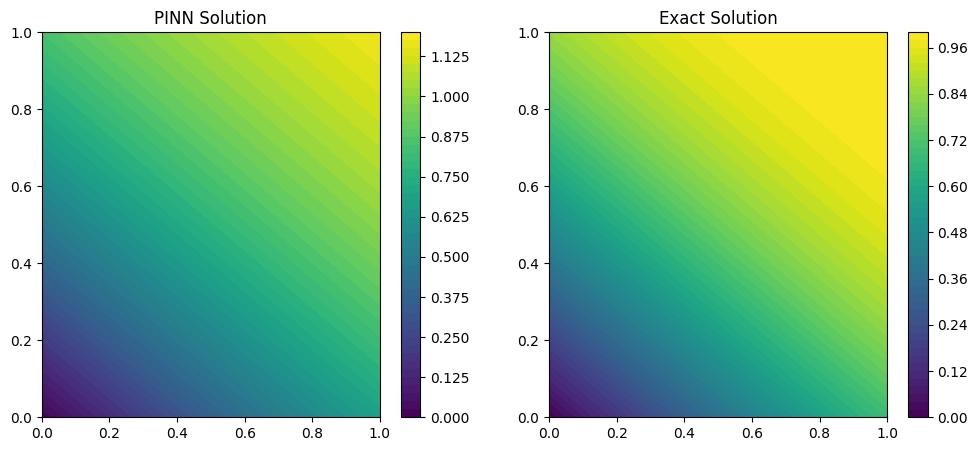

In [21]:
# exact solution for comparison
def exact_solution(x, y):
    return g(y - (b/a)*x)

# check the solution on a grid
x = torch.linspace(0, 1, 100)
y = torch.linspace(0, 1, 100)
X, Y = torch.meshgrid(x, y)
XY = torch.cat([X.unsqueeze(-1), Y.unsqueeze(-1)], dim=-1).view(-1, 2)
with torch.no_grad():
    U_pred = model(XY).view(100, 100)
U_exact = exact_solution(X, Y)
# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("PINN Solution")
plt.contourf(X, Y, U_pred.numpy(), levels=50, cmap='viridis')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("Exact Solution")
plt.contourf(X, Y, U_exact.numpy(), levels=50, cmap='viridis')
plt.colorbar()
plt.show() 
